# Visualizing Bulk-To-Bulk Testing
Multiple kinds of OT have been tested on the bulk-to-bulk datasets. Here, we will visualize the R2 values that were found for each parameter to the SCC values, as well as correspondence between methods.

## Importing Functions

In [ ]:
### Importing Cooler Files ###
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress
import re
from pathlib import Path
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, bin_contact_map, get_cool_name, hic_ot_source_to_targets

# Importing SCC data
scc_file = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/mouse_scc_chr1/mouse_chr1_scc.csv'
scc_scores_1mb = pd.read_csv(scc_file, index_col=0)
scc_scores_flatten = scc_scores_1mb.values.flatten()

# Setting Data Directory
datadir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Bulk-to-bulk'

## Helper Functions

In [3]:
def compare_to_scc_df(ot_results_df : pd.DataFrame):
    ''' 
        Uses OT results dataframe to compare ot loss to scc scores.
        
        This function is very specific to this notebook.

        Parameters
        ----------
        ot_results_df : pd.DataFrame
            OT results.
        
        Returns
        -------
        rsqr : float
            R^2 values of the fit with SCC scores.
    '''

    # SCC comparison regression
    ot_results_flatten = ot_results_df.values.flatten()
    regression = linregress(ot_results_flatten, scc_scores_flatten)
    rsqr = regression.rvalue**2

    return rsqr

def calculate_correspondence(results_df1 : pd.DataFrame, results_df2 : pd.DataFrame, plot : bool = False):
    '''
        Calculates linear R^2 value between two ot result dataframes.

        Parameters
        ----------
        results_df1 : pd.DataFrame
            Dataframe of ot results.
        results_df2 : pd.DataFrame
            Dataframe of ot results.
        plot : bool
            Controls whether the results are plotted.
            Default = False.
        
        Returns
        -------
        rsqr : float
            R^2 value for linear regression between the two datasets.
    '''

    # Flatten values
    flatten1 = results_df1.values.flatten()
    flatten2 = results_df2.values.flatten()

    # Linear regression
    regression = linregress(flatten1, flatten2)
    intercept = regression.intercept
    slope = regression.slope
    rsqr = regression.rvalue**2

    # Plotting regression
    if plot:
        plt.scatter(flatten1, flatten2, label="Data")
        plt.plot(flatten1, intercept + slope * flatten1, color='red',
                label=f'Linear fit (R\u00b2 = {rsqr:.3f})')
        plt.xlabel("OT loss df1")
        plt.ylabel("OT loss df2")
        plt.legend()
        plt.grid(alpha=0.3)

    return rsqr

def load_ot_results(folder):
    folder = Path(folder)
    
    # Storage dictionaries
    exact = {}          # (resolution, threshold) → DataFrame
    regularized = {}    # lambda → DataFrame   (fixed: 8mb, threshold = 0)
    unbalanced = {}     # (reg_m, resolution, threshold) → DataFrame

    # Regex patterns
    pattern_exact = re.compile(
        r"balanced_bulk_to_bulk_(\d+)mb_(\d+)\.csv"
    )
    pattern_reg = re.compile(
    r"balanced_reg_([0-9]*\.?[0-9]+(?:e-?\d+)?)_bulk_to_bulk_8mb_0\.csv",
    re.IGNORECASE
    )
    pattern_unbalanced = re.compile(
        r"unbalanced_(\d+\.?\d*)_bulk_to_bulk_(\d+)mb_(\d+)\.csv"
    )

    for file in folder.glob("*.csv"):
        name = file.name

        # ---- Exact OT ----
        m = pattern_exact.match(name)
        if m:
            resolution = int(m.group(1))
            threshold = int(m.group(2))
            df = pd.read_csv(file, index_col=0)
            exact[(resolution, threshold)] = df
            continue
        
        # ---- Regularized OT ----
        m = pattern_reg.match(name)
        if m:
            lam = float(m.group(1))
            df = pd.read_csv(file, index_col=0)
            regularized[lam] = df
            continue

        # ---- Unbalanced OT ----
        m = pattern_unbalanced.match(name)
        if m:
            reg_m = float(m.group(1))
            resolution = int(m.group(2))
            threshold = int(m.group(3))
            df = pd.read_csv(file, index_col=0)
            unbalanced[(reg_m, resolution, threshold)] = df
            continue

    return exact, regularized, unbalanced

## Importing Data

In [4]:
### Importing OT results ###
exact, regularized, unbalanced = load_ot_results(datadir)

In [47]:
### Importing times and r2 values
uot_regm_results = pd.read_csv(f"{datadir}/uot_regm_results.csv")
reg_results = pd.read_csv(f"{datadir}/balanced_reg_results.csv")
uot_01_comptimes = pd.read_csv(f"{datadir}/unbalanced_0.1_comptimes.csv", index_col=0)
uot_01_comptimes.columns = uot_01_comptimes.columns.astype(int)
uot_01_r2values = pd.read_csv(f"{datadir}/unbalanced_0.1_r2values.csv", index_col=0)
uot_01_r2values.columns = uot_01_r2values.columns.astype(int)

## Plotting Exact
See comparing_thresholds.ipynb

## Plotting reg_m

In [6]:
### Calculating Correspondence ###
# Extract dfs with 8 mb threshold 0, unbalanced
unbalanced_8mb_0 = {
    (reg_m, res, th): df
    for (reg_m, res, th), df in unbalanced.items()
    if res == 8 and th == 0
}

# Extract balanced 8 mb, 0
balanced_8mb_0 = exact[(8, 0)]

# Add all 8 mb, 0 to df
dataframes_regm = {
    ("balanced", 8, 0): balanced_8mb_0,
}

for (reg_m, res, th), df in unbalanced_8mb_0.items():
    dataframes_regm[("unbalanced", reg_m, res, th)] = df

# Vectorizing matrices
regm_vectors = {}

for key, df in dataframes_regm.items():
    vec = df.stack()
    regm_vectors[key] = vec

regm_vector_df = pd.DataFrame(regm_vectors)

# Compute R2
regm_r2 = []
regm_cols = regm_vector_df.columns

for col1 in regm_cols:
    for col2 in regm_cols:
        x = regm_vector_df[col1].values
        y = regm_vector_df[col2].values
        regression = linregress(x, y)
        r2 = regression.rvalue ** 2
        regm_r2.append((col1, col2, r2))

# Make strings readable
def key_to_str(k):
    if k[0] == "balanced":
        # ("balanced", resolution, threshold)
        return f"OT_{k[1]}mb_{k[2]}"
    else:
        # ("unbalanced", reg_m, res, th)
        return f"UOT_regm_{k[1]}_{k[2]}mb_{k[3]}"

regm_r2_df = pd.DataFrame(regm_r2, columns=["matrix_1", "matrix_2", "R²"])
regm_r2_df["matrix_1"] = regm_r2_df["matrix_1"].apply(key_to_str)
regm_r2_df["matrix_2"] = regm_r2_df["matrix_2"].apply(key_to_str)

# Pivot to matrix form
regm_r2_matrix = regm_r2_df.pivot(index="matrix_1", columns="matrix_2", values="R²")
regm_r2_matrix


matrix_2,OT_8.0mb_0,UOT_regm_0.0001_8mb_0.0,UOT_regm_0.001_8mb_0.0,UOT_regm_0.01_8mb_0.0,UOT_regm_0.1_8mb_0.0,UOT_regm_0.5_8mb_0.0,UOT_regm_1.0_8mb_0.0,UOT_regm_10.0_8mb_0.0,UOT_regm_100.0_8mb_0.0,UOT_regm_1000.0_8mb_0.0,UOT_regm_10000.0_8mb_0.0
matrix_1,,,,,,,,,,,
OT_8.0mb_0,1.000000,0.978802,0.978802,0.978802,0.978802,0.978802,0.978802,0.970297,0.913326,0.351275,0.095455
UOT_regm_0.0001_8mb_0.0,0.978802,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.997710,0.957697,0.432970,0.149382
UOT_regm_0.001_8mb_0.0,0.978802,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.997710,0.957697,0.432970,0.149382
UOT_regm_0.01_8mb_0.0,0.978802,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.997710,0.957697,0.432970,0.149382
UOT_regm_0.1_8mb_0.0,0.978802,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.997710,0.957697,0.432970,0.149382
UOT_regm_0.5_8mb_0.0,0.978802,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.997710,0.957697,0.432970,0.149382
UOT_regm_1.0_8mb_0.0,0.978802,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.997710,0.957697,0.432970,0.149382
UOT_regm_10.0_8mb_0.0,0.970297,0.997710,0.997710,0.997710,0.997710,0.997710,0.997710,1.000000,0.966962,0.454942,0.165712
UOT_regm_100.0_8mb_0.0,0.913326,0.957697,0.957697,0.957697,0.957697,0.957697,0.957697,0.966962,1.000000,0.626833,0.311397


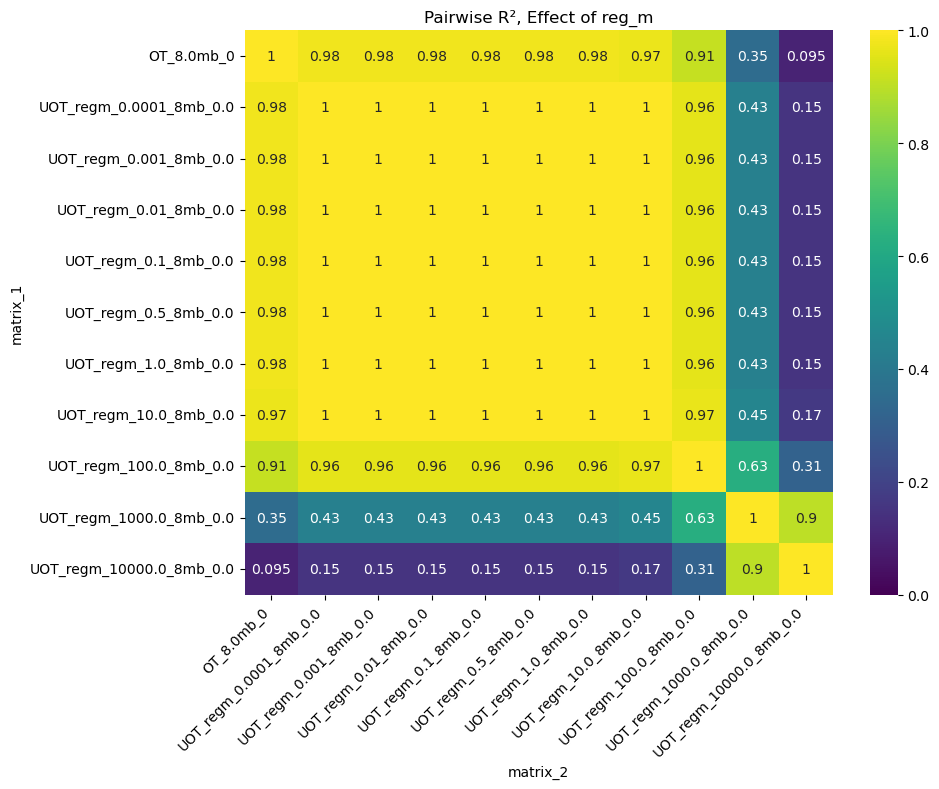

In [7]:
### Plotting ###
plt.figure(figsize=(10,8))
sns.heatmap(regm_r2_matrix, annot=True, cmap="viridis", vmin=0, vmax=1)
plt.title("Pairwise R\u00b2, Effect of reg_m")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Plotting Regularization

In [8]:
### Calculating Correspondence ###

# Add all 8 mb, 0 to df
dataframes_reg = {
    ("exact", 8, 0): balanced_8mb_0,
}

for reg, df in regularized.items():
    dataframes_reg[("regularized", reg)] = df

# Vectorizing matrices
reg_vectors = {}

for key, df in dataframes_reg.items():
    vec = df.stack()
    reg_vectors[key] = vec

reg_vector_df = pd.DataFrame(reg_vectors)

# Compute R2
reg_r2 = []
reg_cols = reg_vector_df.columns

for col1 in reg_cols:
    for col2 in reg_cols:
        x = reg_vector_df[col1].values
        y = reg_vector_df[col2].values
        regression = linregress(x, y)
        r2 = regression.rvalue ** 2
        reg_r2.append((col1, col2, r2))

# Make strings readable
def key_to_str(k):
    if k[0] == "exact":
        # ("exact", resolution, threshold)
        return f"exact_{k[1]}mb_{k[2]}"
    else:
        reg = k[1]
        # ("regularized", reg, res, th)
        reg = f"{reg:.8f}".rstrip("0").rstrip(".")
        return f"regularized_reg_{reg}_8mb_0"

reg_r2_df = pd.DataFrame(reg_r2, columns=["matrix_1", "matrix_2", "R²"])
reg_r2_df["matrix_1"] = reg_r2_df["matrix_1"].apply(key_to_str)
reg_r2_df["matrix_2"] = reg_r2_df["matrix_2"].apply(key_to_str)

# Pivot to matrix form
reg_r2_matrix = reg_r2_df.pivot(index="matrix_1", columns="matrix_2", values="R²")
reg_r2_matrix


matrix_2,exact_8.0mb_0.0,regularized_reg_0.00001_8mb_0,regularized_reg_0.0001_8mb_0,regularized_reg_0.001_8mb_0,regularized_reg_0.01_8mb_0,regularized_reg_0.1_8mb_0,regularized_reg_1_8mb_0
matrix_1,,,,,,,
exact_8.0mb_0.0,1.000000,0.135573,0.135573,0.428232,0.925993,0.989351,0.991938
regularized_reg_0.00001_8mb_0,0.135573,1.000000,1.000000,0.034578,0.132465,0.140198,0.164656
regularized_reg_0.0001_8mb_0,0.135573,1.000000,1.000000,0.034578,0.132465,0.140198,0.164656
regularized_reg_0.001_8mb_0,0.428232,0.034578,0.034578,1.000000,0.323276,0.401232,0.439094
regularized_reg_0.01_8mb_0,0.925993,0.132465,0.132465,0.323276,1.000000,0.935387,0.933924
regularized_reg_0.1_8mb_0,0.989351,0.140198,0.140198,0.401232,0.935387,1.000000,0.991913
regularized_reg_1_8mb_0,0.991938,0.164656,0.164656,0.439094,0.933924,0.991913,1.000000


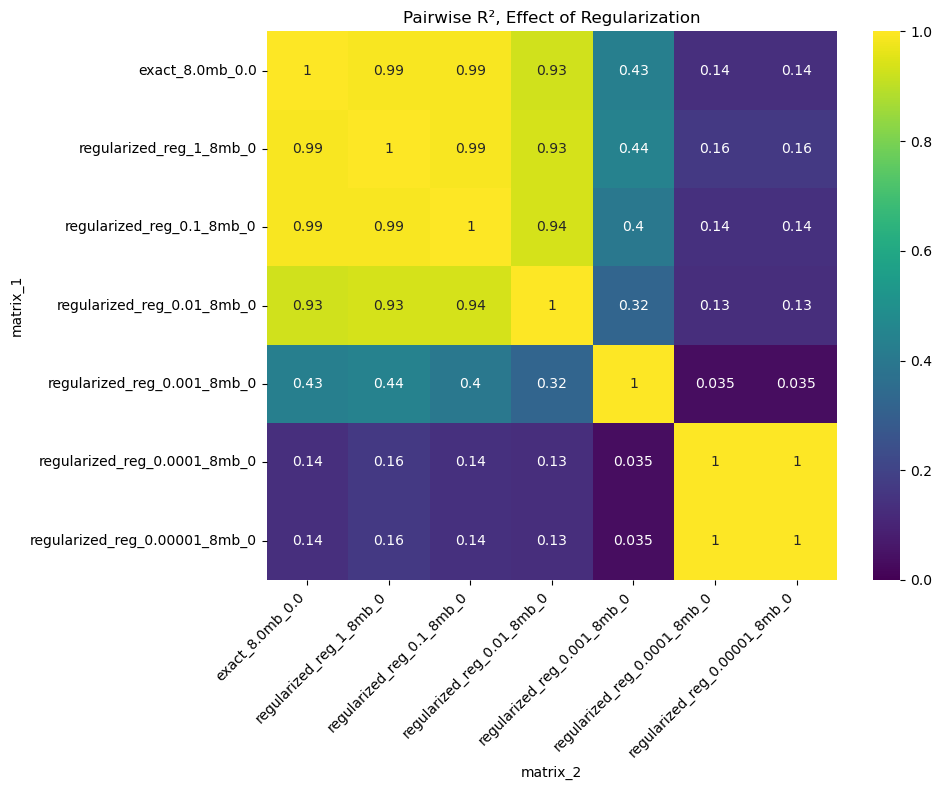

In [9]:
### Plotting ###
order = sorted(reg_r2_df['matrix_1'].unique(), key=lambda x: (str(x.split("_")[0]), 1 - float(x.split('_')[2])), reverse=False)
reg_r2_matrix = reg_r2_matrix.loc[order, order]
plt.figure(figsize=(10,8))
sns.heatmap(reg_r2_matrix, annot=True, cmap="viridis", vmin=0, vmax=1)
plt.title("Pairwise R\u00b2, Effect of Regularization")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Plotting UOT

### Plots

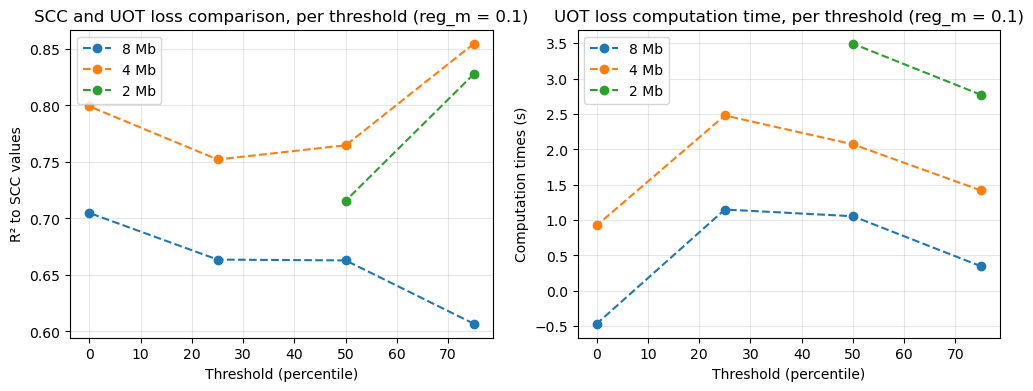

In [ ]:
### Plotting by resolution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R2 values
axes[0].plot(uot_01_r2values[8], 'o--', label="8 Mb")
axes[0].plot(uot_01_r2values[4], 'o--', label="4 Mb")
axes[0].plot(uot_01_r2values[2], 'o--', label="2 Mb")
axes[0].set_xlabel("Threshold (percentile)")
axes[0].set_ylabel("R\u00b2 to SCC values")
axes[0].set_title("SCC and UOT loss comparison, per threshold (reg_m = 0.1)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Computation times
axes[1].plot(np.log10(uot_01_comptimes[8]), 'o--', label="8 Mb")
axes[1].plot(np.log10(uot_01_comptimes[4]), 'o--', label="4 Mb")
axes[1].plot(np.log10(uot_01_comptimes[2]), 'o--', label="2 Mb")
axes[1].set_xlabel("Threshold (percentile)")
axes[1].set_ylabel("Computation times (log(s))")
axes[1].set_title("UOT loss computation time, per threshold (reg_m = 0.1)")
axes[1].legend()
axes[1].grid(alpha=0.3)

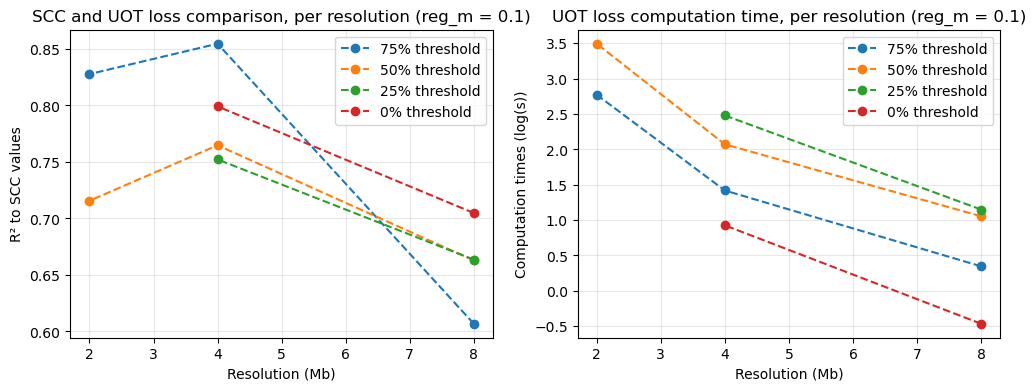

In [63]:
### Plotting by resolution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R2 values
axes[0].plot(uot_01_r2values.loc[75], 'o--', label="75% threshold")
axes[0].plot(uot_01_r2values.loc[50], 'o--', label="50% threshold")
axes[0].plot(uot_01_r2values.loc[25], 'o--', label="25% threshold")
axes[0].plot(uot_01_r2values.loc[0], 'o--', label="0% threshold")
axes[0].set_xlabel("Resolution (Mb)")
axes[0].set_ylabel("R\u00b2 to SCC values")
axes[0].set_title("SCC and UOT loss comparison, per resolution (reg_m = 0.1)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Computation times
axes[1].plot(np.log10(uot_01_comptimes.loc[75]), 'o--', label="75% threshold")
axes[1].plot(np.log10(uot_01_comptimes.loc[50]), 'o--', label="50% threshold")
axes[1].plot(np.log10(uot_01_comptimes.loc[25]), 'o--', label="25% threshold")
axes[1].plot(np.log10(uot_01_comptimes.loc[0]), 'o--', label="0% threshold")
axes[1].set_xlabel("Resolution (Mb)")
axes[1].set_ylabel("Computation times (log(s))")
axes[1].set_title("UOT loss computation time, per resolution (reg_m = 0.1)")
axes[1].legend()
axes[1].grid(alpha=0.3)

### Heatmaps

In [ ]:
### Calculating Correspondence ###
# Extract unbalanced dfs with reg_m = 0.1
unbalanced_regm_01 = {
    (reg_m, res, th): df
    for (reg_m, res, th), df in unbalanced.items()
    if reg_m == 0.1
}

# Extracting balanced dfs with threshold 0
balanced_thres_0 = {
    (res, th): df
    for (res, th), df in exact.items()
    if th == 0
}

# Empty dict for dfs
dataframes_uot = {}

# Adding to dict
for (res, th), df in balanced_thres_0.items():
    dataframes_uot[("exact", res, th)] = df

for (reg_m, res, th), df in unbalanced_regm_01.items():
    dataframes_uot[("unbalanced", reg_m, res, th)] = df

# Vectorizing matrices
uot_vectors = {}

for key, df in dataframes_uot.items():
    vec = df.stack()
    uot_vectors[key] = vec

uot_vector_df = pd.DataFrame(uot_vectors)

# Compute R2
uot_r2 = []
uot_cols = uot_vector_df.columns

for col1 in uot_cols:
    for col2 in uot_cols:
        x = uot_vector_df[col1].values
        y = uot_vector_df[col2].values
        regression = linregress(x, y)
        r2 = regression.rvalue ** 2
        uot_r2.append((col1, col2, r2))

# Make strings readable
def key_to_str(k):
    if k[0] == "exact":
        # ("balanced", resolution, threshold)
        return f"OT_{k[1]}mb_{k[2]}"
    else:
        # ("unbalanced", res, th)
        return f"UOT_{k[2]}mb_{k[3]}"

uot_r2_df = pd.DataFrame(uot_r2, columns=["matrix_1", "matrix_2", "R²"])
uot_r2_df["matrix_1"] = uot_r2_df["matrix_1"].apply(key_to_str)
uot_r2_df["matrix_2"] = uot_r2_df["matrix_2"].apply(key_to_str)

# Pivot to matrix form
uot_r2_matrix = uot_r2_df.pivot(index="matrix_1", columns="matrix_2", values="R²")
uot_r2_matrix

matrix_2,OT_2.0mb_0,OT_4.0mb_0,OT_8.0mb_0,UOT_2mb_50.0,UOT_2mb_75.0,UOT_4mb_0.0,UOT_4mb_25.0,UOT_4mb_50.0,UOT_4mb_75.0,UOT_8mb_0.0,UOT_8mb_25.0,UOT_8mb_50.0,UOT_8mb_75.0
matrix_1,,,,,,,,,,,,,
OT_2.0mb_0,1.000000,0.996580,0.984060,0.431607,0.470707,0.800330,0.670054,0.685880,0.659143,0.970358,0.756753,0.698175,0.584980
OT_4.0mb_0,0.996580,1.000000,0.993837,0.470346,0.506732,0.824517,0.706090,0.726032,0.689937,0.977241,0.780462,0.734999,0.597515
OT_8.0mb_0,0.984060,0.993837,1.000000,0.520054,0.559471,0.848123,0.744577,0.774306,0.740103,0.978802,0.812518,0.776886,0.630116
UOT_2mb_50.0,0.431607,0.470346,0.520054,1.000000,0.966561,0.815497,0.886727,0.883279,0.818235,0.560007,0.663776,0.729996,0.491473
UOT_2mb_75.0,0.470707,0.506732,0.559471,0.966561,1.000000,0.816813,0.874887,0.896072,0.889892,0.589845,0.689207,0.758625,0.572528
UOT_4mb_0.0,0.800330,0.824517,0.848123,0.815497,0.816813,1.000000,0.890329,0.884996,0.834149,0.898441,0.763678,0.766099,0.537215
UOT_4mb_25.0,0.670054,0.706090,0.744577,0.886727,0.874887,0.890329,1.000000,0.968462,0.897369,0.756684,0.895129,0.897078,0.695130
UOT_4mb_50.0,0.685880,0.726032,0.774306,0.883279,0.896072,0.884996,0.968462,1.000000,0.929400,0.772880,0.894863,0.938909,0.702686
UOT_4mb_75.0,0.659143,0.689937,0.740103,0.818235,0.889892,0.834149,0.897369,0.929400,1.000000,0.732161,0.849541,0.861998,0.788419


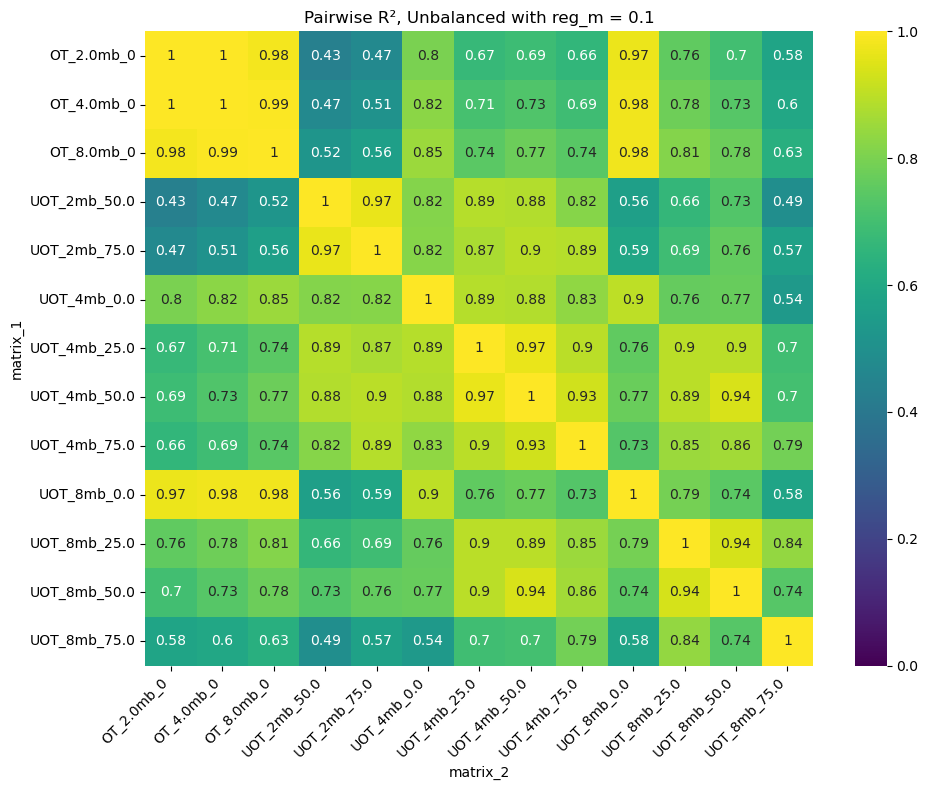

In [27]:
### Plotting ###
order = sorted(uot_r2_df['matrix_1'].unique(), key=lambda x: (str(x.split('_')[0]), str(x.split('_')[1]), float(x.split('_')[2])))
uot_r2_matrix_order = uot_r2_matrix.loc[order, order]
plt.figure(figsize=(10,8))
sns.heatmap(uot_r2_matrix_order, annot=True, cmap="viridis", vmin=0, vmax=1)
plt.title("Pairwise R\u00b2, Unbalanced with reg_m = 0.1")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()